In [1]:
import tensorflow as tf
from tensorflow import keras
from keras.datasets import imdb

In [2]:
(train_data, train_labels), (test_data, test_labels) = imdb.load_data(num_words=10000)


In [3]:
# num words oznacza ze w treningowym zbiorze danych zostanie zachowanych tylko 10 k slow wystepujacych najczesciej w tym zbiorze danych, slowa 
#wystepujace rzadziej beda pominiete. rozwiazanie te umozliwia prace z wektorem danych o rozmiarze umozliwiajacynm jego przetwarzanie

In [4]:
train_data

array([list([1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]),
       list([1, 194, 1153, 194, 8255, 78, 228,

In [5]:
train_labels

array([1, 0, 0, ..., 0, 1, 0], shape=(25000,))

In [6]:
max([max(sequence) for sequence in train_data])

9999

In [7]:
word_index = imdb.get_word_index()
reverse_word_index = dict(
    [(value,key) for (key, value) in word_index.items()])
decoded_review = ' '.join(
    [reverse_word_index.get(i - 3, '?') for i in train_data[0]])

In [8]:
decoded_review

"? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for ? and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also ? to the two little boy's that played the ? of norman and paul they were just brilliant children are often left out of the ? list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be praised for what they have done don't you th

In [9]:
# przetlumaczona caly kod z numerycznych na tekst - train data [0]

In [10]:
# zamiana na wektory liczb 0 i 1

In [11]:
import numpy as np

In [12]:
def vectorize_sequences(sequences, dimension = 10000):
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1
    return results
x_train = vectorize_sequences(train_data)
x_train

array([[0., 1., 1., ..., 0., 0., 0.],
       [0., 1., 1., ..., 0., 0., 0.],
       [0., 1., 1., ..., 0., 0., 0.],
       ...,
       [0., 1., 1., ..., 0., 0., 0.],
       [0., 1., 1., ..., 0., 0., 0.],
       [0., 1., 1., ..., 0., 0., 0.]], shape=(25000, 10000))

In [13]:
x_test = vectorize_sequences(test_data)
x_test

array([[0., 1., 1., ..., 0., 0., 0.],
       [0., 1., 1., ..., 0., 0., 0.],
       [0., 1., 1., ..., 0., 0., 0.],
       ...,
       [0., 1., 1., ..., 0., 0., 0.],
       [0., 1., 1., ..., 0., 0., 0.],
       [0., 1., 1., ..., 0., 0., 0.]], shape=(25000, 10000))

In [14]:
train_labels

array([1, 0, 0, ..., 0, 1, 0], shape=(25000,))

In [15]:
y_train = np.asarray(train_labels).astype('float32')
y_test = np.asarray(test_labels).astype('float32')

In [16]:
y_train

array([1., 0., 0., ..., 0., 1., 0.], shape=(25000,), dtype=float32)

In [17]:
from keras import models
from keras import layers

In [64]:
model = models.Sequential()
model.add(layers.Dense(16, activation='relu', input_shape=(10000,)))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

In [65]:
# kompilacja modelu

In [66]:
model.compile(optimizer = 'rmsprop',
              loss = 'binary_crossentropy',
              metrics = ['accuracy'])

In [67]:
# konfiguracja optymalizatora

In [68]:
from keras import optimizers

In [69]:
model.compile(optimizer=optimizers.RMSprop(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [70]:
# korzystanie z wlasnych funkcji straty i metryki

In [71]:
from keras import losses
from keras import metrics

model.compile(optimizer=optimizers.RMSprop(learning_rate=0.001),
              loss=losses.binary_crossentropy,
              metrics=[metrics.binary_accuracy])

In [72]:
# tworzenie zbioru walidacyjnego

In [73]:
x_val = x_train[:10000]
partial_x_train = x_train[10000:]

In [74]:
y_val = y_train[:10000]
partial_y_train = y_train[10000:]

In [75]:
# trenowanie modelu

In [76]:
model.compile(optimizer = 'rmsprop',
              loss = 'binary_crossentropy',
              metrics = ['acc'])

In [77]:
history = model.fit(partial_x_train,
                    partial_y_train,
                    epochs=20,
                    batch_size=512,
                    validation_data=(x_val, y_val))

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - acc: 0.7699 - loss: 0.5519 - val_acc: 0.8509 - val_loss: 0.4292
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - acc: 0.8902 - loss: 0.3464 - val_acc: 0.8751 - val_loss: 0.3317
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - acc: 0.9153 - loss: 0.2589 - val_acc: 0.8819 - val_loss: 0.2969
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - acc: 0.9296 - loss: 0.2098 - val_acc: 0.8885 - val_loss: 0.2759
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - acc: 0.9423 - loss: 0.1759 - val_acc: 0.8838 - val_loss: 0.2867
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - acc: 0.9523 - loss: 0.1476 - val_acc: 0.8860 - val_loss: 0.2829
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - acc: 0.9595 - loss: 0.1279 - val_acc: 0.8748 - val_loss: 0.3216
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - acc: 0.9668 - loss: 0.1103 - val_acc: 0.8843 - val_loss: 0.3017
Epoch 9/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - acc: 0.9727 - loss:

In [78]:
history_dict = history.history
history_dict.keys()

dict_keys(['acc', 'loss', 'val_acc', 'val_loss'])

In [79]:
import matplotlib.pyplot as plt

In [80]:
acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']

In [81]:
epochs = range(1, len(acc) + 1)

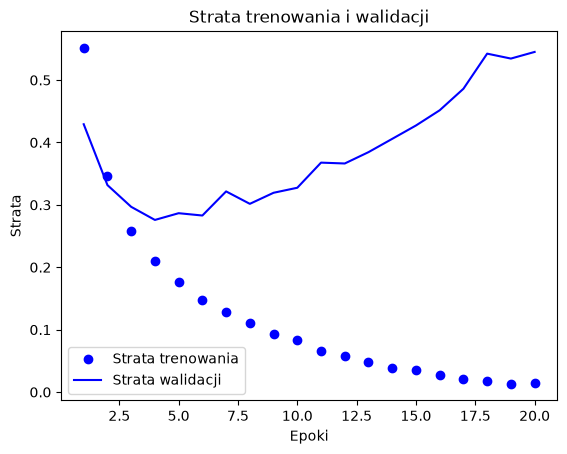

In [82]:
plt.plot(epochs, loss, 'bo', label='Strata trenowania')
plt.plot(epochs, val_loss, 'b', label='Strata walidacji')
plt.title('Strata trenowania i walidacji')
plt.xlabel('Epoki')
plt.ylabel('Strata')
plt.legend()

plt.show()

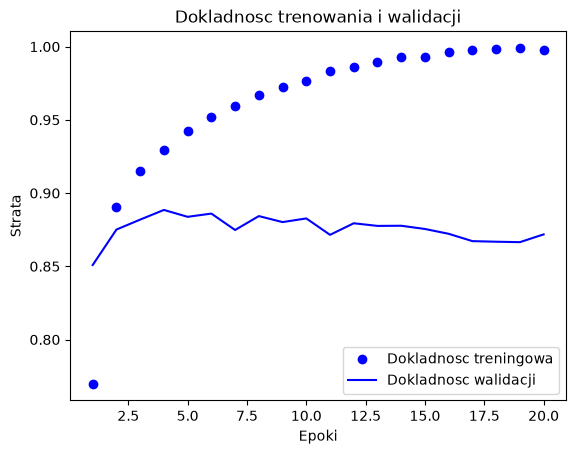

In [83]:
plt.clf()
acc_values = history_dict['acc']
val_acc_values = history_dict['val_acc']

plt.plot(epochs, acc, 'bo', label='Dokladnosc treningowa')
plt.plot(epochs, val_acc, 'b', label='Dokladnosc walidacji')
plt.title('Dokladnosc trenowania i walidacji')
plt.xlabel('Epoki')
plt.ylabel('Strata')
plt.legend()

plt.show()

In [84]:
model = models.Sequential()
model.add(layers.Dense(16, activation='relu', input_shape=(10000,)))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

model.compile(optimizer = 'rmsprop',
              loss = 'binary_crossentropy',
              metrics = ['accuracy'])

model.fit(x_train, y_train, epochs=4, batch_size=512)
results = model.evaluate(x_test, y_test)

Epoch 1/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8071 - loss: 0.4942
Epoch 2/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8964 - loss: 0.2985
Epoch 3/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9190 - loss: 0.2286
Epoch 4/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9291 - loss: 0.1947
782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 749us/step - accuracy: 0.8842 - loss: 0.2913


In [85]:
results

[0.29131224751472473, 0.8842399716377258]

In [86]:
model.predict(x_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 589us/step


array([[0.25606024],
       [0.999145  ],
       [0.93328875],
       ...,
       [0.11465218],
       [0.1146466 ],
       [0.73015094]], shape=(25000, 1), dtype=float32)

# zadanie 2

In [154]:
from keras.datasets import reuters

In [155]:
(train_data_2, train_labels_2), (test_data_2, test_labels_2) = reuters.load_data(num_words=10000)

In [156]:
len(train_data_2)

8982

In [157]:
len(test_data_2)

2246

In [178]:
train_data_2

array([list([1, 2, 2, 8, 43, 10, 447, 5, 25, 207, 270, 5, 3095, 111, 16, 369, 186, 90, 67, 7, 89, 5, 19, 102, 6, 19, 124, 15, 90, 67, 84, 22, 482, 26, 7, 48, 4, 49, 8, 864, 39, 209, 154, 6, 151, 6, 83, 11, 15, 22, 155, 11, 15, 7, 48, 9, 4579, 1005, 504, 6, 258, 6, 272, 11, 15, 22, 134, 44, 11, 15, 16, 8, 197, 1245, 90, 67, 52, 29, 209, 30, 32, 132, 6, 109, 15, 17, 12]),
       list([1, 3267, 699, 3434, 2295, 56, 2, 7511, 9, 56, 3906, 1073, 81, 5, 1198, 57, 366, 737, 132, 20, 4093, 7, 2, 49, 2295, 2, 1037, 3267, 699, 3434, 8, 7, 10, 241, 16, 855, 129, 231, 783, 5, 4, 587, 2295, 2, 2, 775, 7, 48, 34, 191, 44, 35, 1795, 505, 17, 12]),
       list([1, 53, 12, 284, 15, 14, 272, 26, 53, 959, 32, 818, 15, 14, 272, 26, 39, 684, 70, 11, 14, 12, 3886, 18, 180, 183, 187, 70, 11, 14, 102, 32, 11, 29, 53, 44, 704, 15, 14, 19, 758, 15, 53, 959, 47, 1013, 15, 14, 19, 132, 15, 39, 965, 32, 11, 14, 147, 72, 11, 180, 183, 187, 44, 11, 14, 102, 19, 11, 123, 186, 90, 67, 960, 4, 78, 13, 68, 467, 511, 110,

In [179]:
# dekodowanie indeksow

In [180]:
word_index = reuters.get_word_index()
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])
decoded_newswire = ' '.join([reverse_word_index.get(i - 3, '?') for i in train_data_2[0]])

In [181]:
decoded_newswire

'? ? ? said as a result of its december acquisition of space co it expects earnings per share in 1987 of 1 15 to 1 30 dlrs per share up from 70 cts in 1986 the company said pretax net should rise to nine to 10 mln dlrs from six mln dlrs in 1986 and rental operation revenues to 19 to 22 mln dlrs from 12 5 mln dlrs it said cash flow per share this year should be 2 50 to three dlrs reuter 3'

In [182]:
train_labels_2

array([ 3,  4,  3, ..., 25,  3, 25], shape=(8982,))

In [183]:
train_data_2.shape

(8982,)

In [184]:
def vectorize_sequences(sequences, dimension = 10000):
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1
    return results
x_train_2 = vectorize_sequences(train_data_2)
x_test_2 = vectorize_sequences(test_data_2)

In [185]:
train_labels_2

array([ 3,  4,  3, ..., 25,  3, 25], shape=(8982,))

In [186]:
test_labels_2

array([ 3, 10,  1, ...,  3,  3, 24], shape=(2246,))

In [187]:
from keras.utils import to_categorical

In [188]:
one_hot_train_labels = to_categorical(train_labels_2)
one_hot_test_labels = to_categorical(test_labels_2)

In [189]:
# definicja modelu

In [190]:
model_2 = models.Sequential([
    layers.Input(shape=(10000,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(46, activation='softmax')
])

In [191]:
# kompilacja modelu

In [192]:
model_2.compile(optimizer='rmsprop',
              loss= 'categorical_crossentropy',
              metrics=['accuracy'])

In [193]:
# zbior kontrolny 

In [198]:
x_val_2 = x_train_2[:1000]
partial_x_train_2 = x_train_2[1000:]

In [199]:
partial_x_train_2

array([[0., 1., 1., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 1., 1., ..., 0., 0., 0.],
       ...,
       [0., 1., 1., ..., 0., 0., 0.],
       [0., 1., 1., ..., 0., 0., 0.],
       [0., 1., 1., ..., 0., 0., 0.]], shape=(7982, 10000))

In [200]:
y_val_2 = one_hot_train_labels[:1000]
partial_y_train_2 = one_hot_train_labels[1000:]

In [201]:
history_2 = model_2.fit(partial_x_train_2,
                        partial_y_train_2,
                        epochs=20,
                        batch_size=512,
                        validation_data=(x_val_2, y_val_2))

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5086 - loss: 2.6838 - val_accuracy: 0.6150 - val_loss: 1.8323
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6743 - loss: 1.5596 - val_accuracy: 0.7020 - val_loss: 1.3970
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7464 - loss: 1.1918 - val_accuracy: 0.7340 - val_loss: 1.1947
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7925 - loss: 0.9650 - val_accuracy: 0.7630 - val_loss: 1.0728
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8282 - loss: 0.7958 - val_accuracy: 0.7690 - val_loss: 1.0064
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8567 - loss: 0.6634 - val_accuracy: 0.8000 - val_loss: 0.9370
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8806 - loss: 0.5559 - val_accuracy: 0.8030 - val_loss: 0.9076
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9018 - loss: 0.4623 - val_accuracy: 0.8050 - val_loss

In [203]:
loss_2 = history_2.history['loss']
val_loss_2 = history_2.history['val_loss']
epochs = range(1, len(loss) + 1)

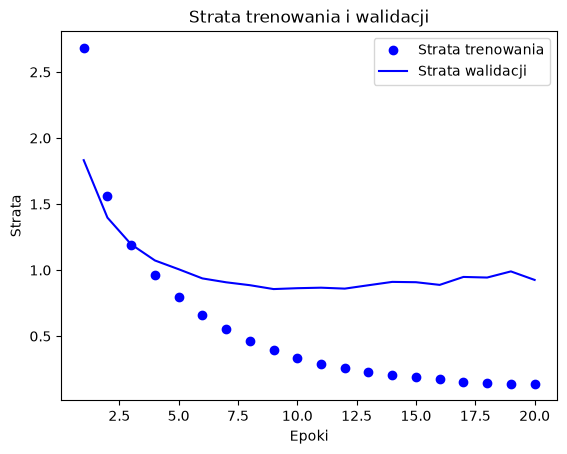

In [210]:
plt.plot(epochs, loss_2, 'bo', label='Strata trenowania')
plt.plot(epochs, val_loss_2, 'b', label='Strata walidacji')
plt.title('Strata trenowania i walidacji')
plt.xlabel('Epoki')
plt.ylabel('Strata')
plt.legend()

plt.show()

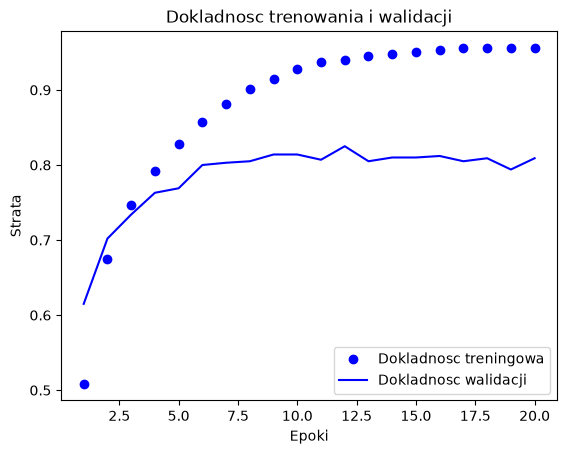

In [213]:
plt.clf()
acc_2 = history_2.history['accuracy']
val_acc_2 = history_2.history['val_accuracy']

plt.plot(epochs, acc_2, 'bo', label='Dokladnosc treningowa')
plt.plot(epochs, val_acc_2, 'b', label='Dokladnosc walidacji')
plt.title('Dokladnosc trenowania i walidacji')
plt.xlabel('Epoki')
plt.ylabel('Strata')
plt.legend()

plt.show()

In [214]:
# tam gdzie val loss jest najmniejszy i val acc najwieksze wybieramy to 

In [215]:
# trenujemy znowu od nowa na 9 epokach

In [216]:
model_2 = models.Sequential([
    layers.Input(shape=(10000,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(46, activation='softmax')
])

model_2.compile(optimizer='rmsprop',
              loss= 'categorical_crossentropy',
              metrics=['accuracy'])

model_2.fit(partial_x_train_2,
            partial_y_train_2,
            epochs=8,
            batch_size=512,
            validation_data=(x_val_2, y_val_2))
results = model_2.evaluate(x_test_2, one_hot_test_labels)

Epoch 1/8
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5124 - loss: 2.6542 - val_accuracy: 0.6400 - val_loss: 1.7972
Epoch 2/8
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6807 - loss: 1.5381 - val_accuracy: 0.6700 - val_loss: 1.4089
Epoch 3/8
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7382 - loss: 1.2095 - val_accuracy: 0.7350 - val_loss: 1.2203
Epoch 4/8
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7846 - loss: 1.0067 - val_accuracy: 0.7660 - val_loss: 1.1149
Epoch 5/8
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8181 - loss: 0.8449 - val_accuracy: 0.7620 - val_loss: 1.0524
Epoch 6/8
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8459 - loss: 0.7140 - val_accuracy: 0.7920 - val_loss: 0.9793
Epoch 7/8
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8690 - loss: 0.6027 - val_accuracy: 0.7960 - val_loss: 0.9479
Epoch 8/8
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8881 - loss: 0.5138 - val_accuracy: 0.8020 - val_loss: 0.9245

In [217]:
results

[0.9974088072776794, 0.7724844217300415]

In [218]:
# generowanie przewidywan

In [219]:
predictions_2 = model_2.predict(x_test_2)

71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 937us/step


In [221]:
len(predictions_2)

2246

In [224]:
predictions_2.shape

(2246, 46)

In [225]:
np.argmax(predictions_2[0])

np.int64(3)

In [226]:
# 3 oznacza ze ten artykul nalezy do kategorii 3

In [228]:
# teraz pokazemy dlaczego warto tworzyc odpowiednio duze warstwy 

In [230]:
model_2 = models.Sequential([
    layers.Input(shape=(10000,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(4, activation='relu'),
    layers.Dense(46, activation='softmax')
])

model_2.compile(optimizer='rmsprop',
              loss= 'categorical_crossentropy',
              metrics=['accuracy'])

model_2.fit(partial_x_train_2,
            partial_y_train_2,
            epochs=20,
            batch_size=128,
            validation_data=(x_val_2, y_val_2))
results_3 = model_2.evaluate(x_test_2, one_hot_test_labels)

Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4453 - loss: 2.7188 - val_accuracy: 0.5570 - val_loss: 1.9987
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6230 - loss: 1.6753 - val_accuracy: 0.6400 - val_loss: 1.5573
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7016 - loss: 1.3492 - val_accuracy: 0.6920 - val_loss: 1.4091
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7220 - loss: 1.1985 - val_accuracy: 0.6960 - val_loss: 1.3559
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7279 - loss: 1.0994 - val_accuracy: 0.6930 - val_loss: 1.3283
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7328 - loss: 1.0180 - val_accuracy: 0.6840 - val_loss: 1.3320
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7388 - loss: 0.9471 - val_accuracy: 0.6930 - val_loss: 1.3300
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7531 - loss: 0.8828 - val_accuracy: 0.6970 - val_loss:

In [231]:
results_3

[1.8251774311065674, 0.6963490843772888]

In [232]:
# dokladnosc spadla o okolo 8

In [233]:
# teraz sprobujemy dac warsty po 128 